<a href="https://colab.research.google.com/github/zemand/r_d-computer-vision-course/blob/main/Homework-5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HOMEWORK 5

In this homework you are going to implement the **Floyd-Steinberg dithering** algorithm. Dithering, in general, means that we are adding noise to the signal (in our case digital image) in order to perceive it better. In other words, by adding the noise the objective quality will be worse but the subjective quality will be better (i.e. the image will "look" better).

The details of FS dithering can be found in this [wiki](https://en.wikipedia.org/wiki/Floyd%E2%80%93Steinberg_dithering) page. In order to implement the dithering, we will implement the following steps:
* Define colour palette
* Quantize the image to obtain the baseline and compute the average quantization error
* Implement FS dithering and compute the average quantization error

You will also have to answer the question at the end of this notebook.

Note: In this homework, you will have the chance to earn some extra points. See the "Bonus" section at the end of the notebook. Good luck!

As always, you are encouraged to use your own images :-)

In [41]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [42]:
import cv2
import math
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

Let's load the image.

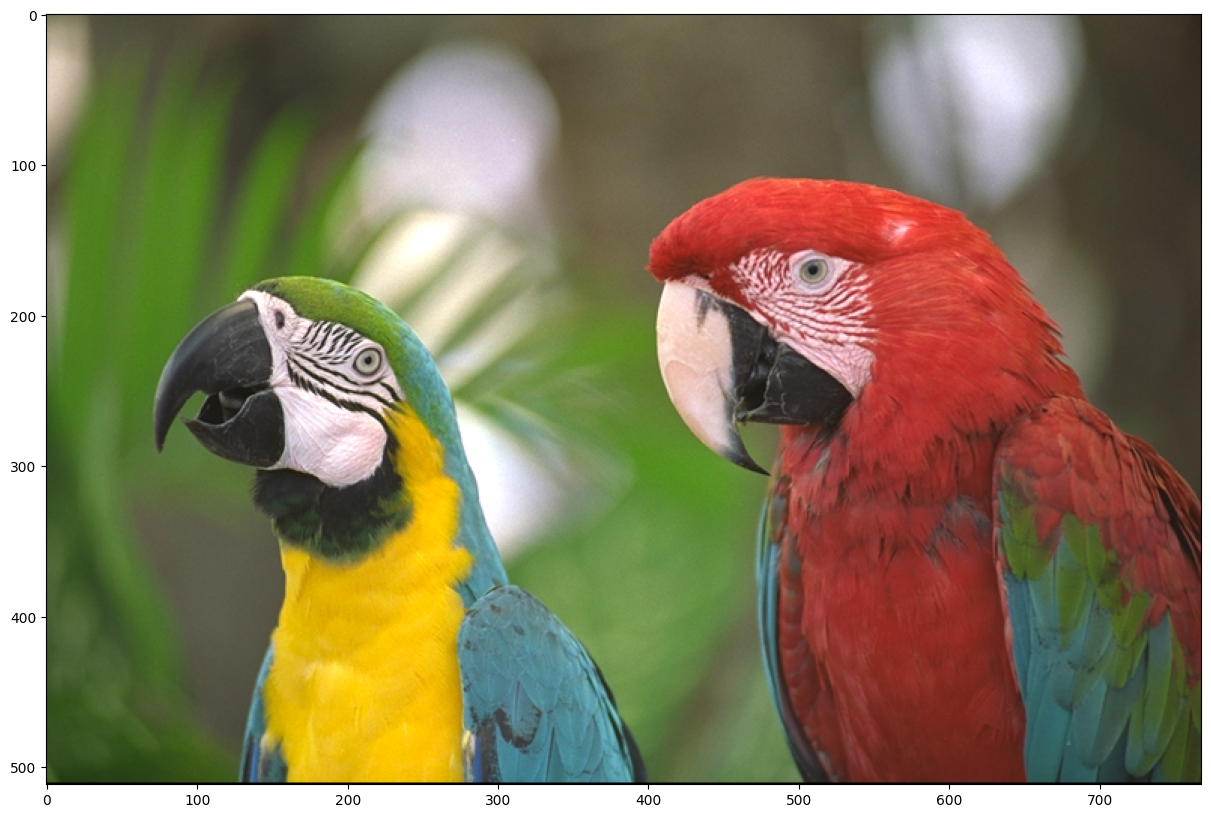

In [43]:
# Load image
img = cv2.imread('/content/drive/MyDrive/Colab Notebooks/Computer-Vision-v2-master/lesson_5/data/kodim23.png')
# Convert it to RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# Plot it
plt.imshow(img)

Let's start with gray tones first.

In [44]:
# Black, dark gray, light gray, white
colors = np.array([[0, 0, 0],
                   [64, 64, 64],
                   [192, 192, 192],
                   [255, 255, 255]])
##colors = np.array([[0, 0, 0], [255, 255, 255]])

Both parts of the homework need the same operation: given a pixel, find the closest colour of the
palette. Let's write it once as a small function and reuse it.

In [45]:
def closest_color(pixel, colors):
    # Compute the distance from the pixel to every colour of the palette
    # Hint: colors - pixel gives you all the differences at once
    distances = np.linalg.norm(colors - pixel, axis=1)
    # Return the colour of the palette with the smallest distance
    return colors[np.argmin(distances)]

Using the colour palette, let's quantize the original image. This is our baseline: every pixel is
replaced by the closest palette colour, independently of its neighbours.

In [46]:
# Cast the image to float (the quantization error can be negative and larger than 255)
img = img.astype(np.float32)

# Prepare for quantization
rows, cols, channels = img.shape
quantized = np.zeros_like(img)

# Apply quantization
for r in range(rows):
    for c in range(cols):
        # Extract the original pixel value
        pixel = img[r, c, :]

        # Find the closest colour from the palette
        new_pixel = closest_color(pixel, colors)

        # Apply quantization
        quantized[r, c, :] = new_pixel

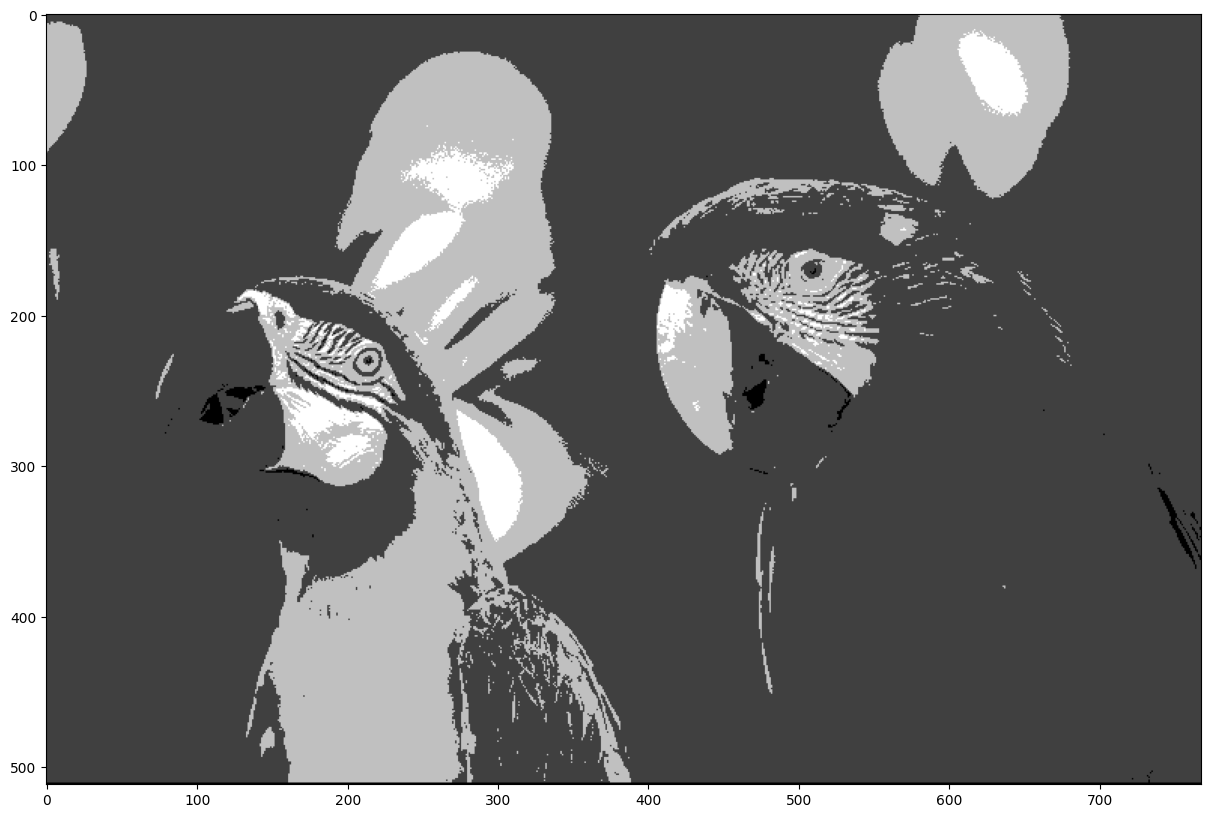

In [47]:
# Show quantized image (don't forget to cast back to uint8)
plt.imshow(quantized.astype(np.uint8))

To be able to compare the two approaches we need a number. Let's use the **average quantization error**,
i.e. the mean absolute difference between the original and the quantized image, averaged over all pixels
and all three channels.

In [48]:
# Compute average quantization error
avg_quant_error = np.mean(np.abs(img - quantized))
print(f"Average Quantization Error: {avg_quant_error}")

Average Quantization Error: 32.75775146484375


#### Floyd-Steinberg Dithering

We are now going to implement the FS dithering and compare it to the optimally quantized image we have
calculated above.

The idea is a **feedback loop**: after quantizing a pixel we know exactly how much we got it wrong,

$$ \varepsilon = p_{orig} - p_{quant} $$

and we push that error onto the neighbours that have not been processed yet. If a pixel was made too
dark, its neighbours are made brighter on purpose, so that the error averages out to zero over a small
area. The error is distributed according to the FS diffusion matrix (`*` marks the current pixel, the
image is scanned left to right, top to bottom)

$$ \frac{1}{16}
\begin{bmatrix}
 - & * & 7 \\
 3 & 5 & 1
\end{bmatrix} $$

so the pixel to the right receives 7/16 of the error, the one below-left 3/16, the one below 5/16 and
the one below-right 1/16.

Two practical notes:
* The diffused error has to be accumulated in a **copy** of the image (`img_tmp`). Each pixel must be
  quantized using the value that already contains the error of its neighbours, not the original value.
* We skip the first and the last row and column so that we do not have to handle the borders, which is
  why the loop starts at 1.

In [49]:
# Make a temporal copy of the original image, we will need it for error diffusion
img_tmp = np.copy(img)
dithering = np.zeros_like(img)

for r in range(1, rows-1):
    for c in range(1, cols-1):
        # Extract the pixel value, including the error diffused from the neighbours
        pixel = img_tmp[r, c, :]

        # Find the closest colour from the palette
        new_pixel = closest_color(pixel, colors)

        # Compute quantization error
        quant_error = pixel - new_pixel

        # Diffuse the quantization error according to the FS diffusion matrix
        # Note: You need more than one line of code here
        img_tmp[r, c+1, :] += quant_error * (7 / 16.0)
        img_tmp[r+1, c-1, :] += quant_error * (3 / 16.0)
        img_tmp[r+1, c, :] += quant_error * (5 / 16.0)
        img_tmp[r+1, c+1, :] += quant_error * (1 / 16.0)

        # Apply dithering
        dithering[r, c, :] = new_pixel

(<Axes: title={'center': 'FS Dithering'}>,
 Text(0.5, 1.0, 'FS Dithering'))

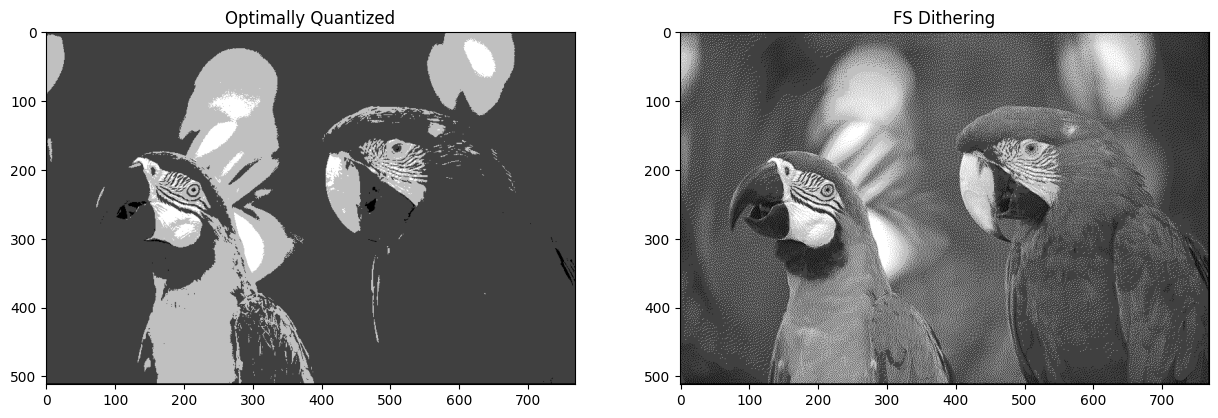

In [50]:
# Show quantized image (don't forget to cast back to uint8)
plt.subplot(121), plt.imshow(quantized.astype(np.uint8)), plt.title('Optimally Quantized')   # optimally quantized
plt.subplot(122), plt.imshow(dithering.astype(np.uint8)), plt.title('FS Dithering')   # dithering

In [51]:
# Compute average quantization error for dithered image
avg_dith_error = np.mean(np.abs(img - dithering))
print(f"Average Dithering Error: {avg_dith_error}")

Average Dithering Error: 41.83168029785156


### Questions
* Which image has higher quantization error? Optimally quantized or dithered?  Dithered зображення має вищу quantization error, це його основна задача коли ми додаємо шум для зменшення помилок між сусідніми пікселями.
---
* Which image looks better to you?
Dithered зображення виглядає набагато краще, на порядок плавніше ніж Optimally quantized.
---


* Can you repeat the same process using only two colours: black and white? Show me :-) Можна змінити масив кольорів: colors = np.array([[0, 0, 0], [255, 255, 255]]), субʼєктивно Optimally quantized виглядає набагато гірше, а dithered +- так само.

### Bonus Points

Repeat the homework using a different image palette. For instance, you can use an optimal colour
palette that we can calculate via k-means algorithm. The following snippet of code will give you the 16
optimal colours for your original image.

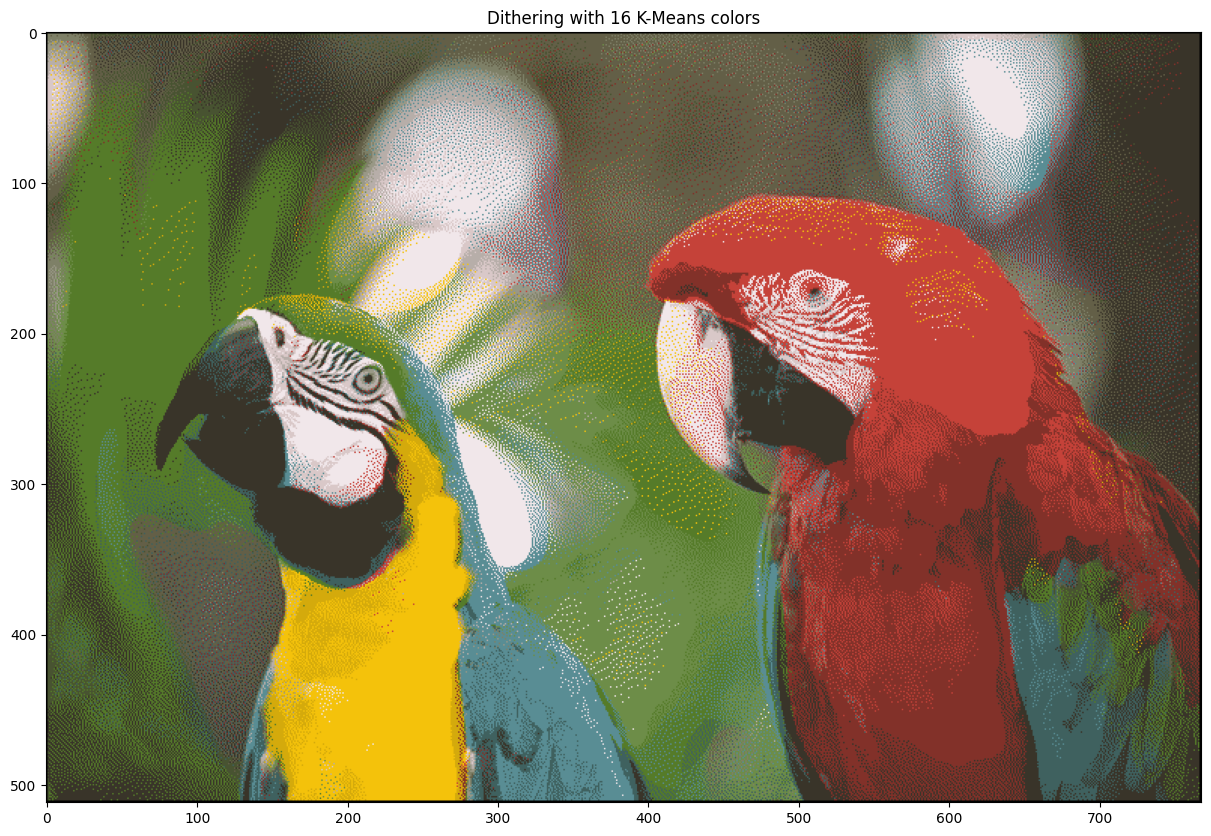

In [52]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=16).fit(np.reshape(img, (-1, 3)))
colors = kmeans.cluster_centers_

# Make a temporal copy of the original image, we will need it for error diffusion
img_tmp = np.copy(img)
dithering = np.zeros_like(img)

for r in range(1, rows-1):
    for c in range(1, cols-1):
        pixel = img_tmp[r, c, :]
        new_pixel = closest_color(pixel, colors)
        quant_error = pixel - new_pixel

        img_tmp[r, c+1, :] += quant_error * (7 / 16.0)
        img_tmp[r+1, c-1, :] += quant_error * (3 / 16.0)
        img_tmp[r+1, c, :] += quant_error * (5 / 16.0)
        img_tmp[r+1, c+1, :] += quant_error * (1 / 16.0)

        dithering[r, c, :] = new_pixel

# Result
plt.imshow(dithering.astype(np.uint8))
plt.title('Dithering with 16 K-Means colors')
plt.show()


Apply FS dithering the same way you did before.
* How does the result look like to you?
Результат з KMeans виглядає реалістичніше, кольори ближчі до оригіналу.

---


* What happens if we use 32 colours?
Шумів менше набагато, але вони все-одно присутні в великій кількості.

---


* And what happens if we use 256 colours?
Практично як оригінал, але шуми якщо приглянутись то теж є, але загалом якісь гарна.